# Data preparation

In [ ]:
# loading data
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
import numpy as np

# setting theme for vis
sns.set_theme(style="darkgrid")

In [ ]:
# creating data frame and selecting columns for analysis
data = pd.read_csv('data.csv', sep = ';', index_col=0, parse_dates=True)#, decimal = ",", encoding='cp1252')
col_of_interest = ['GDP at market prices', 'Exports','Consumption: Private consumption',
                   'Consumption: Public consumption', 'Total fixed investments', 'Imports']
df = data[col_of_interest].copy()
df.head()

,GDP at market prices,Exports,Consumption: Private consumption,Consumption: Public consumption,Total fixed investments,Imports
Year,,,,,,
1950-01-01,5061.770670,454.862029,3532.350088,572.059746,1044.822946,516.398468
1951-01-01,6011.069737,659.065626,4185.629525,677.074995,1234.066578,758.917403
1952-01-01,6505.266311,607.280157,4515.465538,755.192616,1416.788025,821.850569
1953-01-01,7227.473291,703.795264,4934.367869,802.805018,1624.436576,867.891782
1954-01-01,7727.142426,760.012851,5108.907617,909.119879,1799.027022,858.758256


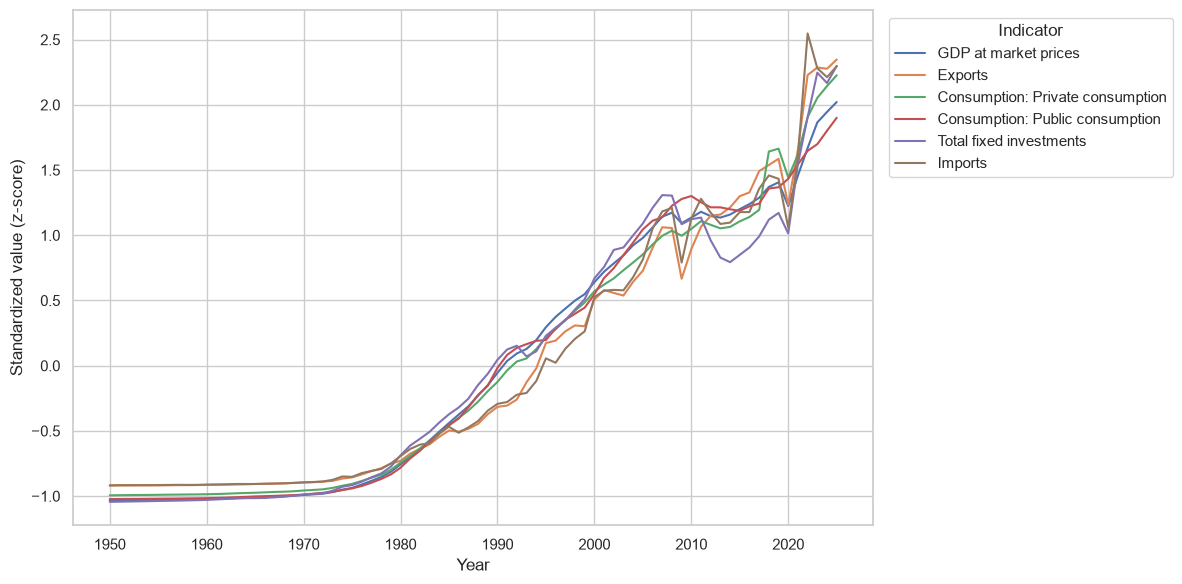

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for col in col_of_interest:
    normalized = (df[col] - df[col].mean()) / df[col].std()  # z-score
    sns.lineplot(x=df.index, y=normalized, ax=ax, label=col)

ax.set_ylabel("Standardized value (z-score)")
ax.legend(title="Indicator", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

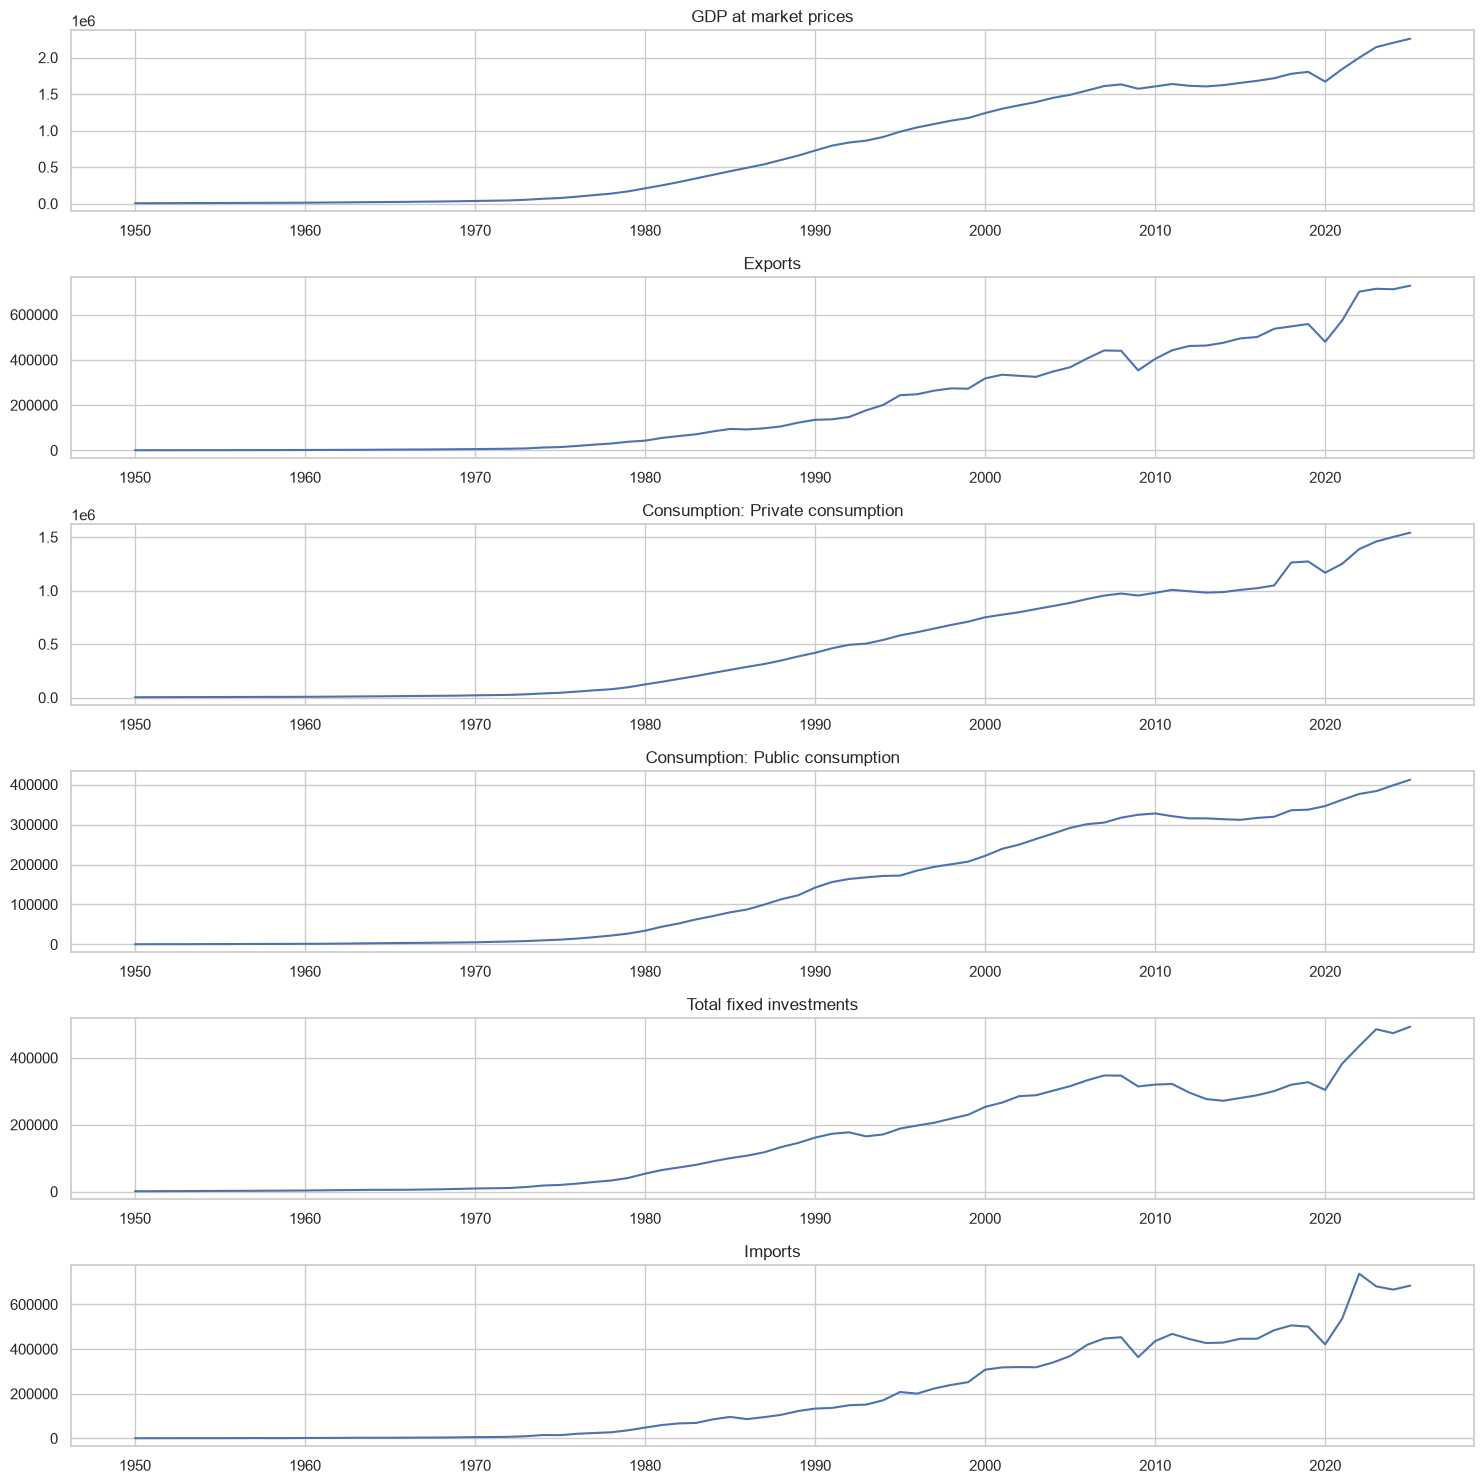

In [ ]:
# plot all series on separate plot
fig, axes = plt.subplots(nrows=len(col_of_interest), figsize=(15, 15))
for ax, column in zip(axes, col_of_interest):
  ax.plot(data.index, data[column])
  ax.set_title(column)
plt.tight_layout()
plt.show()

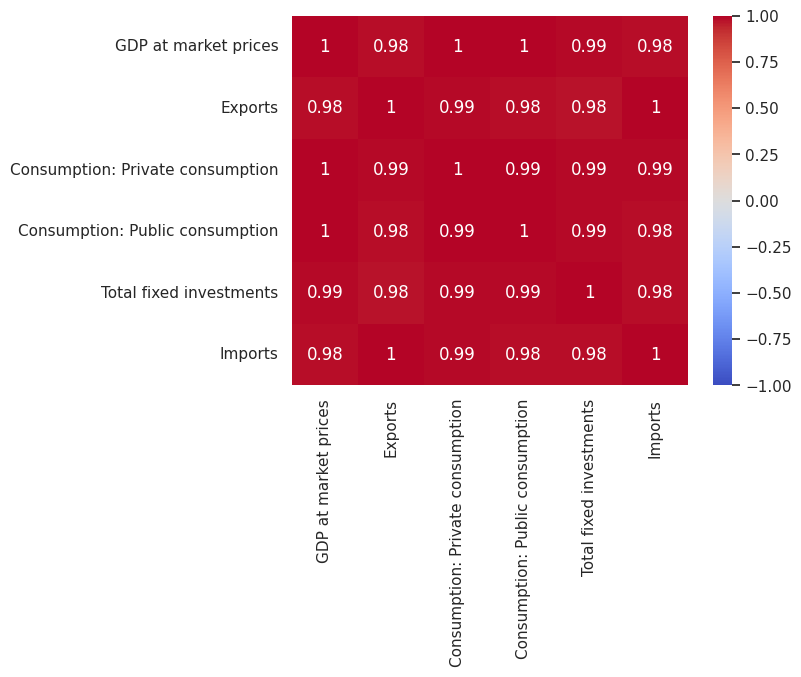

In [ ]:
# correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

**High correlation -> common trend (population grow). Try again after differencing.**

In [ ]:
# check outliers
for col in col_of_interest:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"Outliers in col {col}:")
  print(len(outliers))

Outliers in col GDP at market prices:
0
Outliers in col Exports:
0
Outliers in col Consumption: Private consumption:
0
Outliers in col Consumption: Public consumption:
0
Outliers in col Total fixed investments:
0
Outliers in col Imports:
0


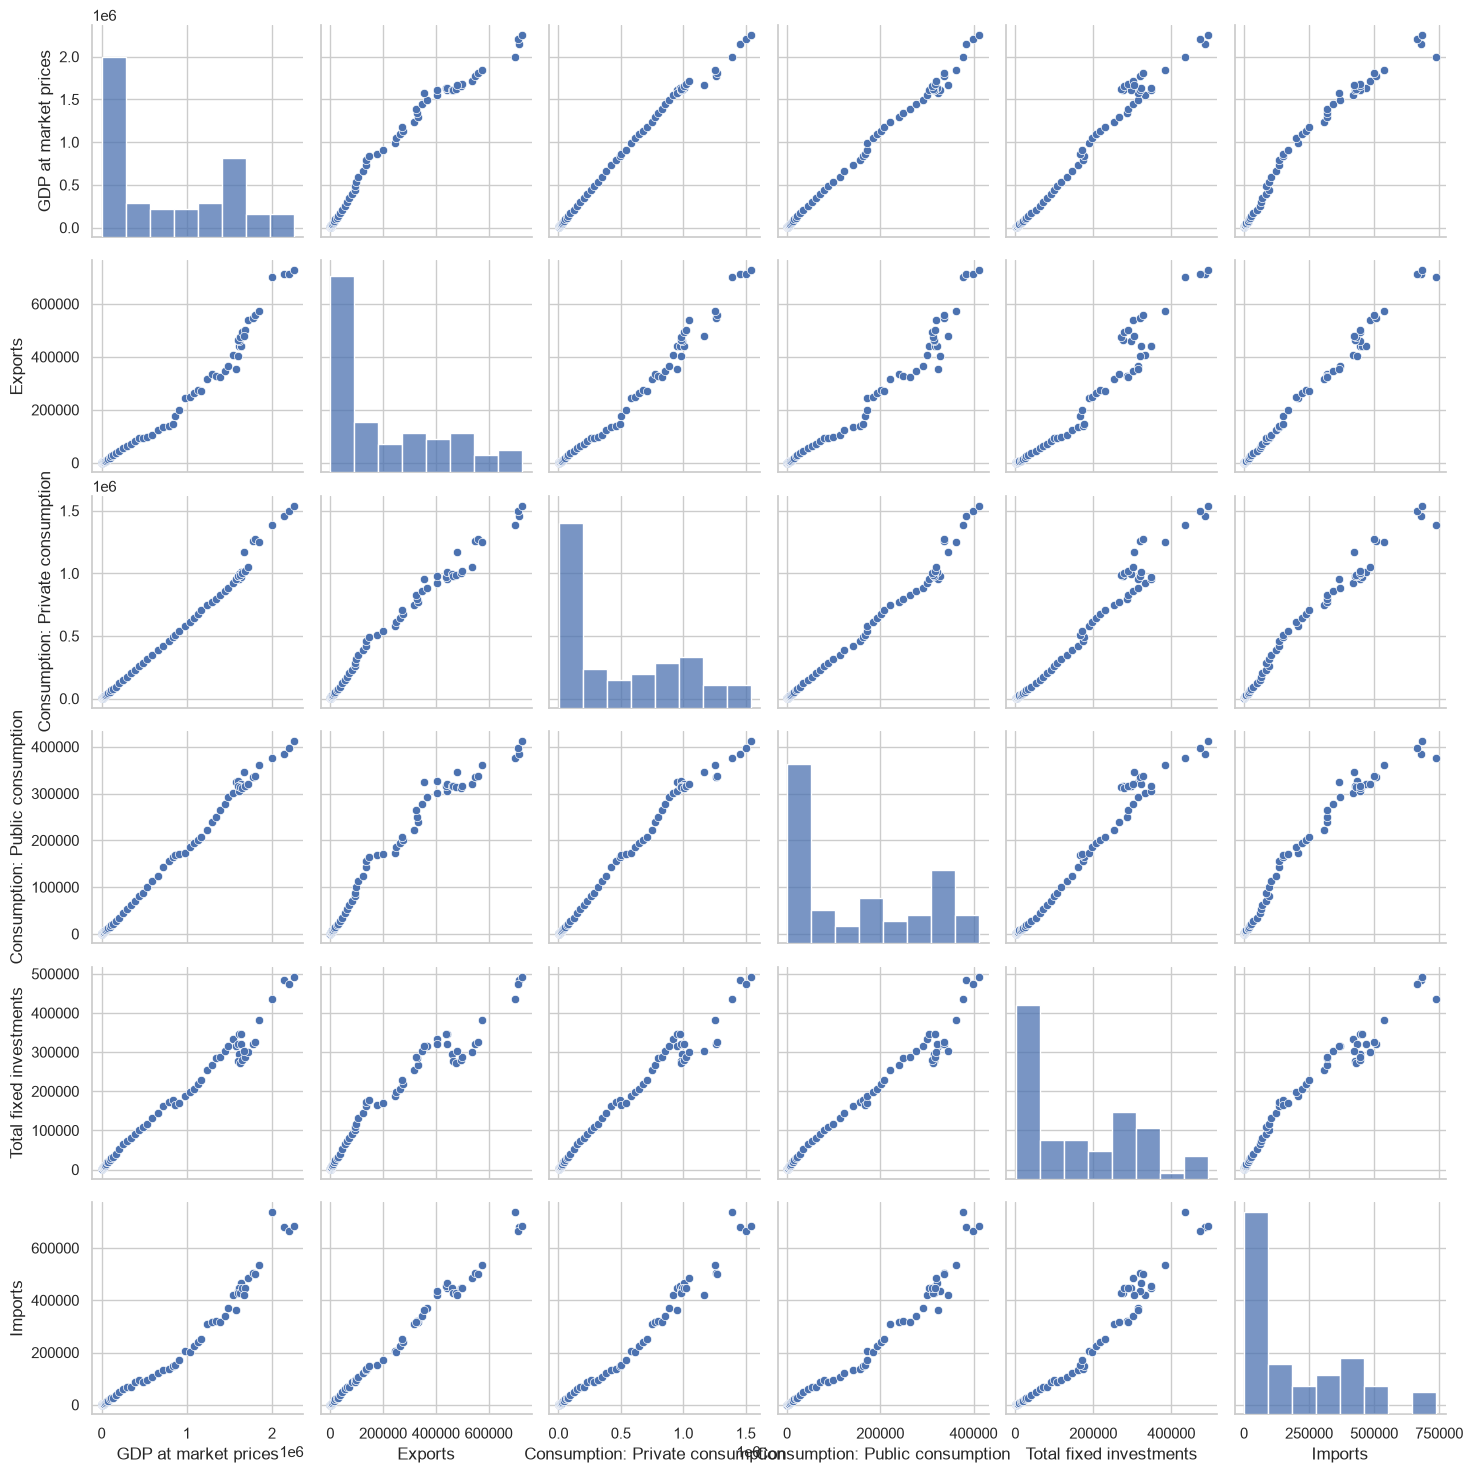

In [ ]:
# plot pairplot
sns.pairplot(df)
plt.show()

# Stationarity

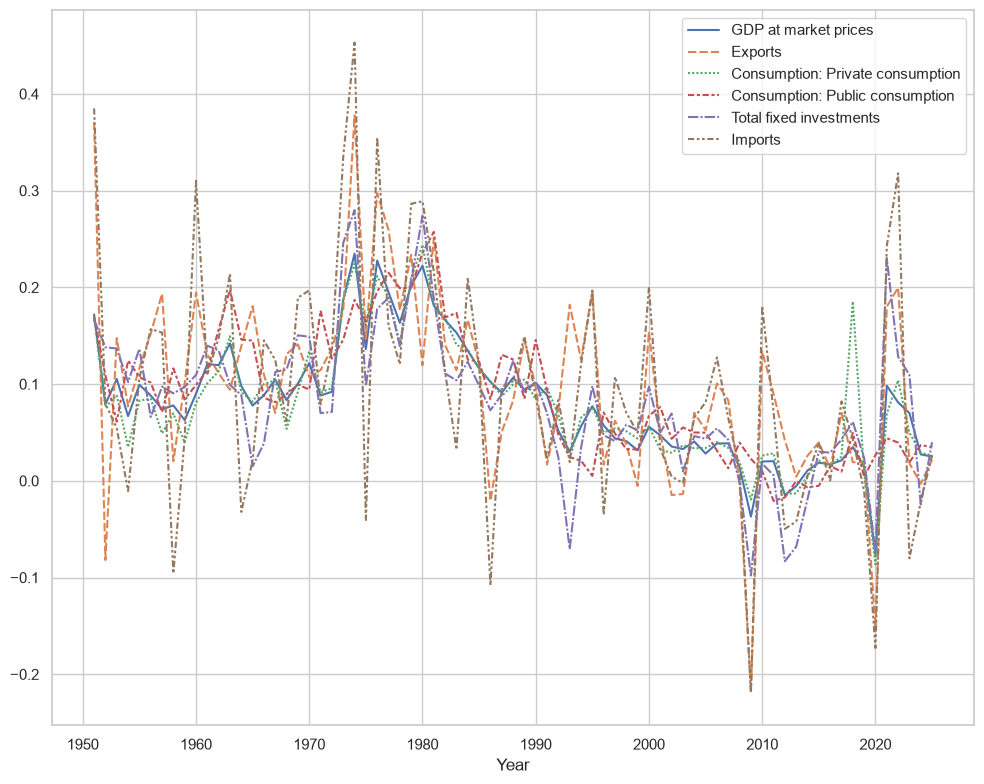

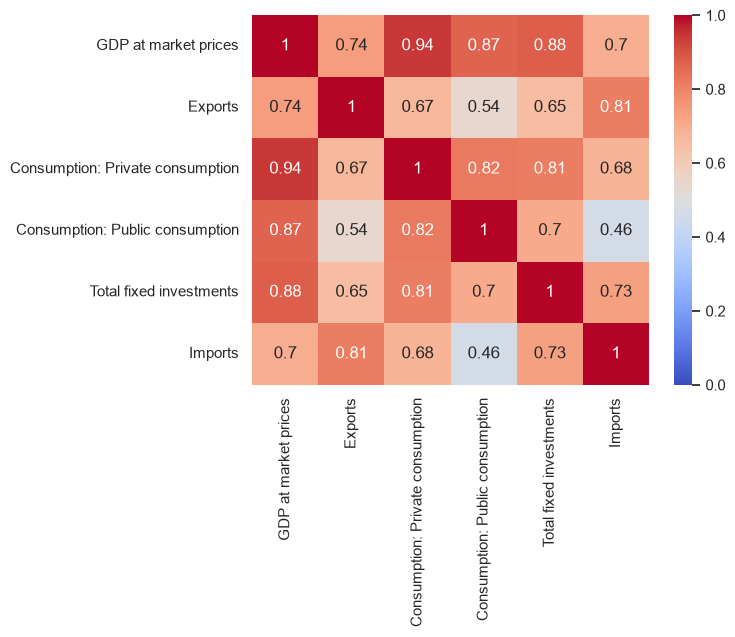

In [ ]:
# Log-transform to stabilise variance and ensure positivity
df_log = np.log(df)

# First difference – usually enough for macro series
df_diff = df_log.diff().dropna()

# plotting new serieses on one plot
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data=df_diff, ax = ax)
plt.tight_layout()
plt.show()

# correlation matrix
corr = df_diff.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.show()

## Check the staionarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test and print results
def adf_test(series, series_name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- {series_name} ---')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical values: {result[4]}')
    if result[1] <= 0.05:
        print('=> Stationary (reject H0)')
    else:
        print('=> Non-stationary (fail to reject H0)')
    print('')

# Apply to all numeric columns (skip the Year column which is index)
for col in df_diff.columns:
    adf_test(df_diff[col], col)

--- GDP at market prices ---
ADF Statistic: -2.161435
p-value: 0.220539
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)

--- Exports ---
ADF Statistic: -1.421249
p-value: 0.572048
Critical values: {'1%': np.float64(-3.53692771987915), '5%': np.float64(-2.907887369384766), '10%': np.float64(-2.591493291015625)}
=> Non-stationary (fail to reject H0)

--- Consumption: Private consumption ---
ADF Statistic: -2.094404
p-value: 0.246771
Critical values: {'1%': np.float64(-3.540522678829176), '5%': np.float64(-2.9094272025108254), '10%': np.float64(-2.5923136524453696)}
=> Non-stationary (fail to reject H0)

--- Consumption: Public consumption ---
ADF Statistic: -1.970791
p-value: 0.299525
Critical values: {'1%': np.float64(-3.5232835753964475), '5%': np.float64(-2.902030597326081), '10%': np.float64(-2.5883710883843123)}
=> Non-stationary (fail to reject H0)

--- Total

Almost all of the serieses are non-stationary. Do differencing twice.

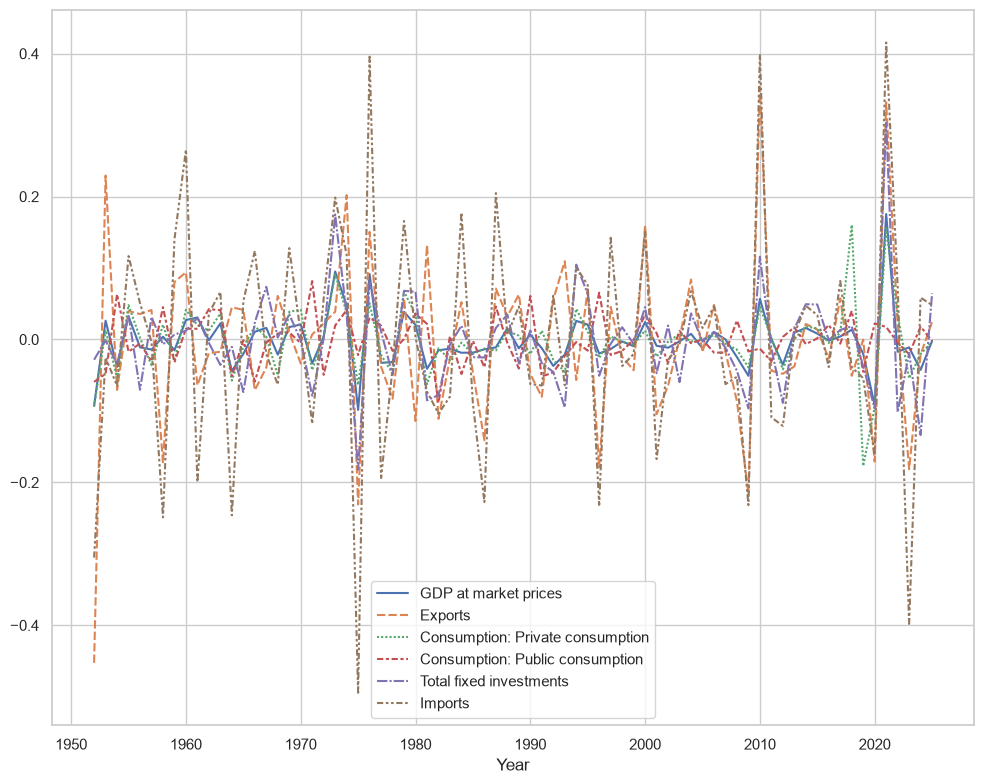

--- GDP at market prices ---
ADF Statistic: -9.276702
p-value: 0.000000
Critical values: {'1%': np.float64(-3.524624466842421), '5%': np.float64(-2.9026070739026064), '10%': np.float64(-2.5886785262345677)}
=> Stationary (reject H0)

--- Exports ---
ADF Statistic: -7.829912
p-value: 0.000000
Critical values: {'1%': np.float64(-3.5274258688046647), '5%': np.float64(-2.903810816326531), '10%': np.float64(-2.5893204081632653)}
=> Stationary (reject H0)

--- Consumption: Private consumption ---
ADF Statistic: -11.893346
p-value: 0.000000
Critical values: {'1%': np.float64(-3.524624466842421), '5%': np.float64(-2.9026070739026064), '10%': np.float64(-2.5886785262345677)}
=> Stationary (reject H0)

--- Consumption: Public consumption ---
ADF Statistic: -11.231781
p-value: 0.000000
Critical values: {'1%': np.float64(-3.5232835753964475), '5%': np.float64(-2.902030597326081), '10%': np.float64(-2.5883710883843123)}
=> Stationary (reject H0)

--- Total fixed investments ---
ADF Statistic: -6.23

In [ ]:
data_diff_2 = df_diff.diff().dropna()

# plotting new serieses on one plot
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data=data_diff_2, ax = ax)
plt.tight_layout()
plt.show()

# Apply to all numeric columns (skip the Year column which is index)
for col in data_diff_2.columns:
    adf_test(data_diff_2[col], col)

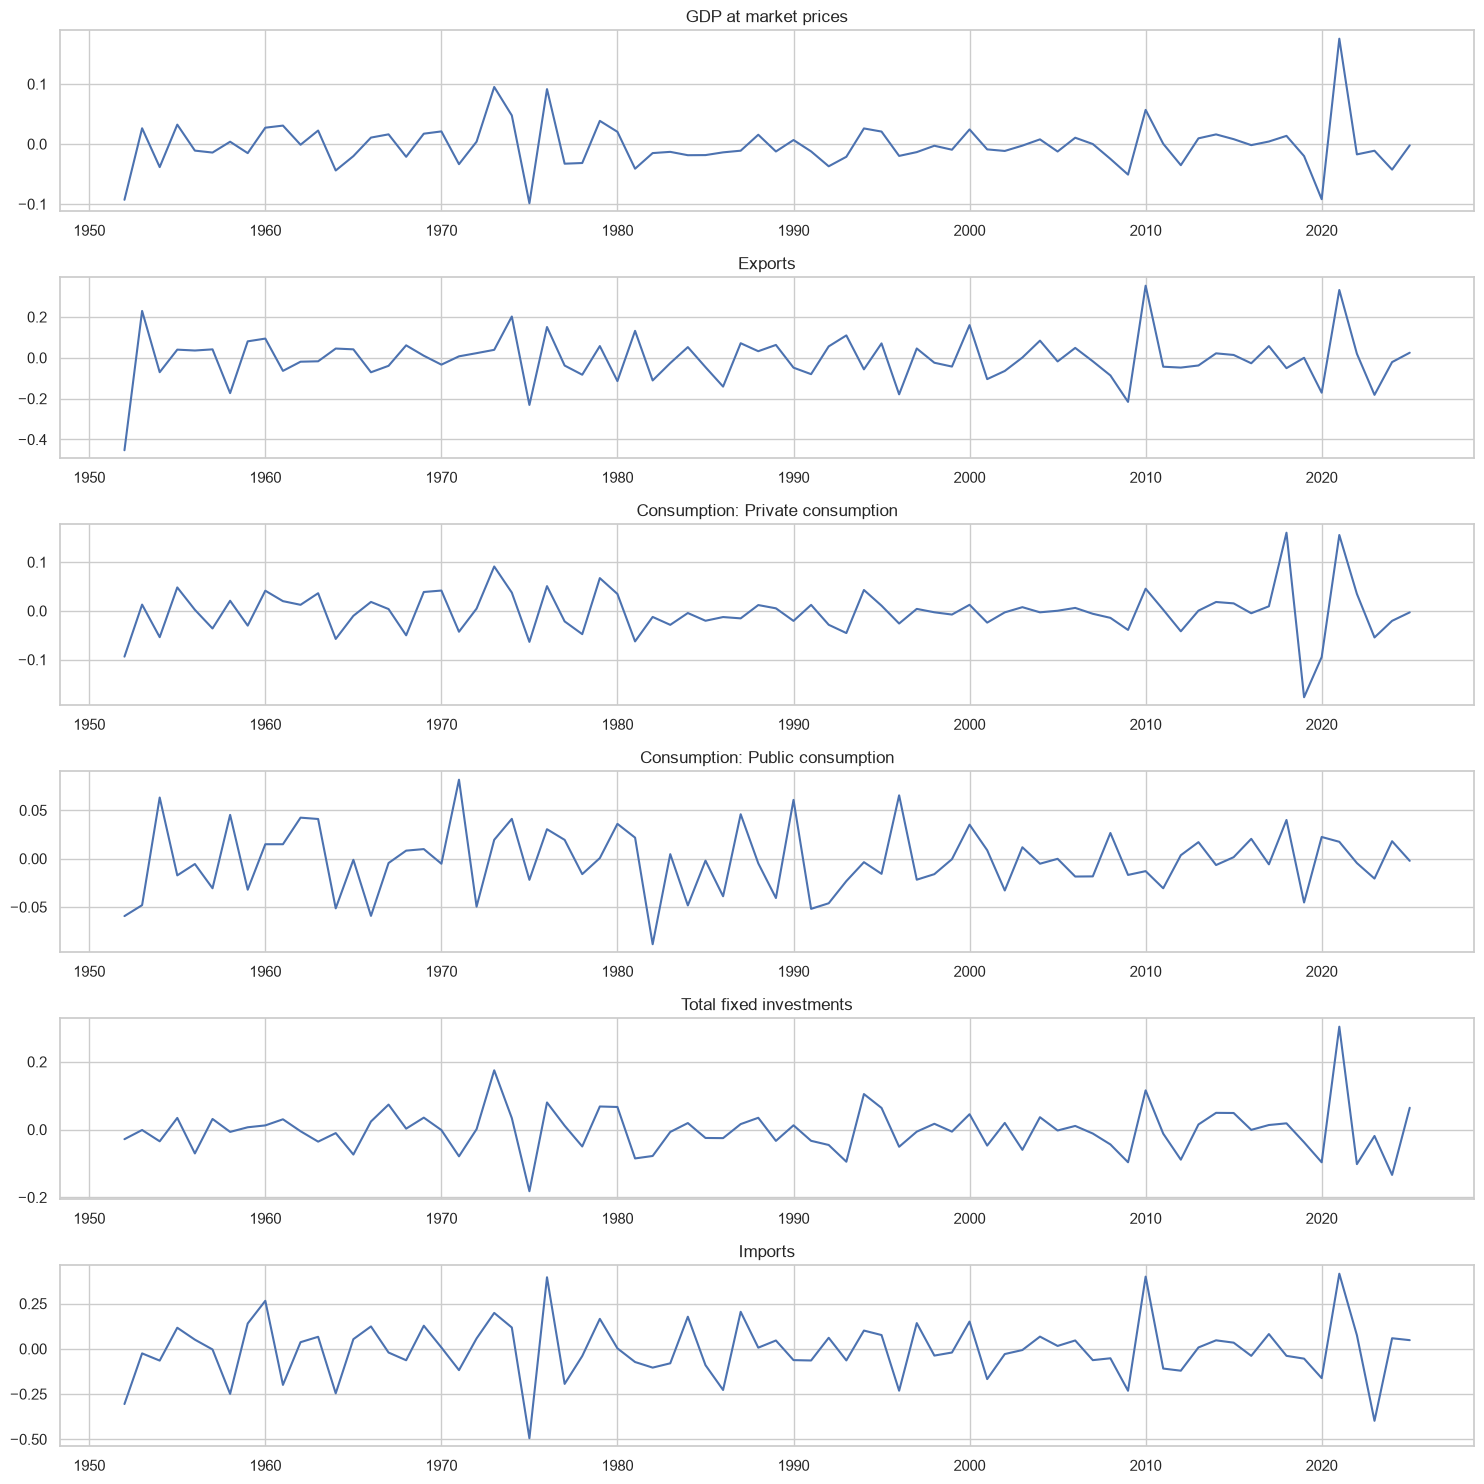

In [ ]:
# plot all series on separate plot
fig, axes = plt.subplots(nrows=len(col_of_interest), figsize=(15, 15))
for ax, column in zip(axes, col_of_interest):
  ax.plot(data_diff_2.index, data_diff_2[column])
  ax.set_title(column)
plt.tight_layout()
plt.show()

## Granger-causality tests

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def build_granger_table(result, maxlag=4):
    rows = []
    for lag in range(1, maxlag + 1):
        # The 'ssr_ftest' returns a tuple: (F_stat, p_value, df_num, df_denom)
        f_test = result[lag][0]['ssr_ftest']

        rows.append({
            'Lags (k)': lag,
            'F-statistic': f_test[0],
            'p-value': f_test[1]
        })
    return pd.DataFrame(rows)

# test what Granger-causes GDP
for col in col_of_interest:
    if col != 'GDP at market prices':
        data_stationary = data_diff_2[['GDP at market prices', col]]
        print(f"\nTesting Granger causality between GDP and {col}:")
        gc_res = grangercausalitytests(data_stationary, maxlag=4, verbose=False)
        table_df = build_granger_table(gc_res)
        print(table_df.to_markdown(index=False, floatfmt=".4f"))
        print(table_df.to_latex(index=False, escape=False))



Testing Granger causality between GDP and Exports:
|   Lags (k) |   F-statistic |   p-value |
|-----------:|--------------:|----------:|
|     1.0000 |        0.2585 |    0.6128 |
|     2.0000 |        2.0635 |    0.1350 |
|     3.0000 |        0.8172 |    0.4891 |
|     4.0000 |        0.5525 |    0.6979 |
\begin{tabular}{rrr}
\toprule
Lags (k) & F-statistic & p-value \\
\midrule
1 & 0.258472 & 0.612771 \\
2 & 2.063503 & 0.135005 \\
3 & 0.817200 & 0.489104 \\
4 & 0.552474 & 0.697930 \\
\bottomrule
\end{tabular}


Testing Granger causality between GDP and Consumption: Private consumption:
|   Lags (k) |   F-statistic |   p-value |
|-----------:|--------------:|----------:|
|     1.0000 |        2.7522 |    0.1016 |
|     2.0000 |       15.8631 |    0.0000 |
|     3.0000 |       10.4203 |    0.0000 |
|     4.0000 |        7.7696 |    0.0000 |
\begin{tabular}{rrr}
\toprule
Lags (k) & F-statistic & p-value \\
\midrule
1 & 2.752216 & 0.101594 \\
2 & 15.863132 & 0.000002 \\
3 & 10.420286 &

d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
#test what is Granger-caused by GDP
for col in col_of_interest:
    if col != 'GDP at market prices':
        data_stationary = data_diff_2[[col, 'GDP at market prices']]
        print(f"\nTesting Granger causality between GDP and {col}:")
        gc_res = grangercausalitytests(data_stationary, maxlag=4, verbose=False)
        table_df = build_granger_table(gc_res)
        print(table_df.to_markdown(index=False, floatfmt=".4f"))
        print(table_df.to_latex(index=False, escape=False))


Testing Granger causality between GDP and Exports:
|   Lags (k) |   F-statistic |   p-value |
|-----------:|--------------:|----------:|
|     1.0000 |        0.3189 |    0.5740 |
|     2.0000 |        1.0016 |    0.3727 |
|     3.0000 |        0.8379 |    0.4781 |
|     4.0000 |        0.4597 |    0.7650 |
\begin{tabular}{rrr}
\toprule
Lags (k) & F-statistic & p-value \\
\midrule
1 & 0.318947 & 0.574047 \\
2 & 1.001639 & 0.372709 \\
3 & 0.837895 & 0.478071 \\
4 & 0.459688 & 0.764979 \\
\bottomrule
\end{tabular}


Testing Granger causality between GDP and Consumption: Private consumption:
|   Lags (k) |   F-statistic |   p-value |
|-----------:|--------------:|----------:|
|     1.0000 |        0.1000 |    0.7527 |
|     2.0000 |        5.0109 |    0.0094 |
|     3.0000 |        4.2815 |    0.0081 |
|     4.0000 |        3.3003 |    0.0163 |
\begin{tabular}{rrr}
\toprule
Lags (k) & F-statistic & p-value \\
\midrule
1 & 0.100039 & 0.752725 \\
2 & 5.010947 & 0.009374 \\
3 & 4.281524 & 0

d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Models

In [ ]:
train_end = '2012-01-01'
test_start = '2013-01-01'

train = data_diff_2.loc[:train_end].copy()
test  = data_diff_2.loc[test_start:].copy()

print(f"\nTrain size: {len(train)} observations")
print(f"Test size : {len(test)} observations")


Train size: 61 observations
Test size : 13 observations


## VAR

### VAR fitted on twice differenced data:

In [ ]:
# Fit VAR
from statsmodels.tsa.api import VAR

model = VAR(train)
lag_order = model.select_order(maxlags=7).aic  # pick min AIC
print(f"\nSelected lag order (AIC): {lag_order}")

results = model.fit(lag_order)
print("\nWhiteness test (should have p > 0.05):")
print(results.test_whiteness())  # check residuals

# Forecast
steps = len(test)
last_obs = train.values[-lag_order:]
forecast_diff_2 = results.forecast(last_obs, steps=steps)

# Reverse second differencing -> get first differences
last_diff_1 = df_diff.loc[train_end]     # last value of first-differenced series (Box-Cox scale)
forecast_diff_1 = np.zeros_like(forecast_diff_2)
forecast_diff_1[0] = last_diff_1.values + forecast_diff_2[0]
for i in range(1, steps):
    forecast_diff_1[i] = forecast_diff_1[i-1] + forecast_diff_2[i]

# Reverse first differencing -> get Box-Cox levels
last_log = df_log.loc[train_end]           # last Box-Cox value before test period
forecast_log = np.zeros_like(forecast_diff_1)
forecast_log[0] = last_log.values + forecast_diff_1[0]
for i in range(1, steps):
    forecast_log[i] = forecast_log[i-1] + forecast_diff_1[i]


# Create DataFrame for forecast
forecast_original = np.exp(forecast_log)
forecast_index = df.index[-steps:]   # same as test index
forecast_df = pd.DataFrame(forecast_original, index=forecast_index, columns=df.columns)
forecast_df


Selected lag order (AIC): 7

Whiteness test (should have p > 0.05):
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 422.654, critical value: 133.257>, p-value: 0.000>


d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,GDP at market prices,Exports,Consumption: Private consumption,Consumption: Public consumption,Total fixed investments,Imports
Year,,,,,,
2013-01-01,1.314749e+06,293024.519318,850756.910131,266530.620733,202831.309461,221252.178639
2014-01-01,1.131917e+06,295376.317216,715421.453630,222716.635874,167868.713265,220797.162255
2015-01-01,9.088884e+05,231379.968312,585408.401132,167473.451918,135098.157589,154938.055849
2016-01-01,7.536703e+05,205280.905225,483071.124397,130749.493784,116328.147195,157144.747027
2017-01-01,5.740646e+05,116534.677627,381566.748814,99343.318652,85474.554466,87267.774860
2018-01-01,4.886539e+05,110080.073806,318798.490359,82083.514779,80900.113906,104513.361983
2019-01-01,3.510178e+05,68870.938688,237443.536411,60543.975346,55788.773719,51819.292546
2020-01-01,2.752494e+05,66071.776061,185015.097976,45021.314468,41219.202785,54564.856933
2021-01-01,1.855379e+05,34198.437631,132349.136535,30041.308744,25028.580539,22553.037668


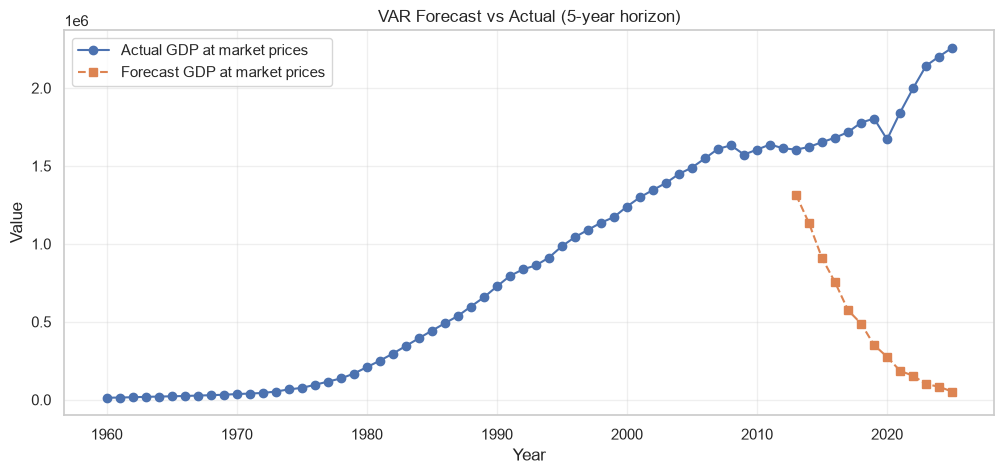

In [ ]:
plt.figure(figsize=(12, 5))
test = df[10:]
for var in df.columns[:1]:   # first three variables
    plt.plot(test.index, test[var], 'o-', label=f'Actual {var}')
    plt.plot(forecast_df.index, forecast_df[var], 's--', label=f'Forecast {var}')
plt.title('VAR Forecast vs Actual (5-year horizon)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The results are awful. The p-vlaue is 0. The model does not work. We try other method.

### VAR on first difference:

In [ ]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Create Exogenous Dummies for Massive Outliers
df_diff['d_covid'] = 0
df_diff['d_gfc'] = 0

# COVID-19 Dummy (The sharpest crash in 2020)
df_diff.loc[(df_diff.index.year >= 2020) & (df_diff.index.year <= 2021), 'd_covid'] = 1

# 2008 Financial Crisis Dummy (Optional but safe)
df_diff.loc[(df_diff.index.year >= 2008) & (df_diff.index.year <= 2009), 'd_gfc'] = 1

# Run ADF on GDP residuals after removing the dummy effect
from sklearn.linear_model import LinearRegression

# Isolate GDP and the dummies
gdp_growth = df_diff['GDP at market prices']
dummies = df_diff[['d_covid', 'd_gfc']]

# Regress out the shock
reg = LinearRegression().fit(dummies, gdp_growth)
residuals_gdp = gdp_growth - reg.predict(dummies)

# Test the residuals for stationarity
adf_result = adfuller(residuals_gdp, autolag='AIC')
print(f"ADF p-value after removing outliers: {adf_result[1]:.4f}")

# Fit the VAR
y = df_diff[col_of_interest]
exog = df_diff[['d_covid', 'd_gfc']]

# Select optimal lag
model = VAR(endog=y, exog=exog)
lag_order = model.select_order(maxlags=5)
optimal_lag = lag_order.aic
print(f"Optimal AIC lag: {optimal_lag}")

# Fit the model WITH the exogenous dummies
fitted_model = model.fit(maxlags=optimal_lag)

# Check the Whiteness Test
whiteness = fitted_model.test_whiteness(nlags=10, signif=0.05)

# Access the p-value properly
print(f"Whiteness Test p-value: {whiteness.pvalue:.4f}")

# Check VAR roots for stability
roots = fitted_model.roots
print(f"VAR Roots (Modulus): {np.abs(roots)}")

ADF p-value after removing outliers: 0.4642
Optimal AIC lag: 2
Whiteness Test p-value: 0.7463
VAR Roots (Modulus): [3.74522135 3.74522135 3.41565562 2.24959461 2.24959461 2.0922831
 2.0922831  2.02768397 2.02768397 1.62223443 1.62223443 1.02338204]


d:\UniWien\Multivariate Time Series\Project\.venv-1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [ ]:
# Fit VAR
from statsmodels.tsa.api import VAR
from scipy.special import inv_boxcox

model = VAR(train)
lag_order = model.select_order(maxlags=5).aic  # pick min AIC
print(f"\nSelected lag order (AIC): {lag_order}")

results = model.fit(lag_order)
print("\nWhiteness test (should have p > 0.05):")
print(results.test_whiteness())  # check residuals

# Forecast
steps = len(test)
last_obs = train.values[-lag_order:]
forecast_diff_2 = results.forecast(last_obs, steps=steps)

# Reverse second differencing -> get first differences
last_diff_1 = df_diff.loc[train_end]     # last value of first-differenced series (Box-Cox scale)
forecast_diff_1 = np.zeros_like(forecast_diff_2)
forecast_diff_1[0] = last_diff_1.values + forecast_diff_2[0]
for i in range(1, steps):
    forecast_diff_1[i] = forecast_diff_1[i-1] + forecast_diff_2[i]

# Reverse first differencing -> get Box-Cox levels
last_log = df_log.loc[train_end]           # last Box-Cox value before test period
forecast_log = np.zeros_like(forecast_diff_1)
forecast_log[0] = last_log.values + forecast_diff_1[0]
for i in range(1, steps):
    forecast_log[i] = forecast_log[i-1] + forecast_diff_1[i]


# Create DataFrame for forecast
forecast_original = np.exp(forecast_log)
forecast_index = df.index[-steps:]   # same as test index
forecast_df = pd.DataFrame(forecast_original, index=forecast_index, columns=df.columns)
forecast_df


Selected lag order (AIC): 5

Whiteness test (should have p > 0.05):
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 285.741, critical value: 212.304>, p-value: 0.000>


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,GDP at market prices,Exports,Consumption: Private consumption,Consumption: Public consumption,Total fixed investments,Imports
Year,,,,,,
2013-01-01,1.529090e+06,451626.930348,944976.455416,293508.287070,252080.892011,362083.859191
2014-01-01,1.460870e+06,422216.937711,896611.537749,275687.747075,228390.859650,333835.064503
2015-01-01,1.412611e+06,432265.012198,872781.492763,258390.035240,221248.352493,352305.817230
2016-01-01,1.352085e+06,427888.519840,843063.943660,241737.614241,210161.337626,338259.841349
2017-01-01,1.310846e+06,428588.625988,820159.998914,230923.514880,198096.948261,337105.655708
2018-01-01,1.260376e+06,398988.409220,798026.919576,223445.026422,183345.158867,312418.429156
2019-01-01,1.189162e+06,391695.710849,751326.305886,210017.046258,164275.908449,288855.112644
2020-01-01,1.133166e+06,393134.023381,721765.771266,194240.362614,149006.771538,284809.163222
2021-01-01,1.088518e+06,387004.776647,700856.068529,179790.184121,137942.430146,275921.336502


In [ ]:
# Fit VAR
from statsmodels.tsa.api import VAR
from scipy.special import inv_boxcox

model = VAR(train)
lag_order = model.select_order(maxlags=5).aic  # pick min AIC
print(f"\nSelected lag order (AIC): {lag_order}")

results = model.fit(lag_order)
print("\nWhiteness test (should have p > 0.05):")
print(results.test_whiteness())  # check residuals

# Forecast
steps = len(test)
last_obs = train.values[-lag_order:]
forecast_diff_2 = results.forecast(last_obs, steps=steps)

# Reverse second differencing -> get first differences
last_diff_1 = df_diff.loc[train_end]     # last value of first-differenced series (Box-Cox scale)
forecast_diff_1 = np.zeros_like(forecast_diff_2)
forecast_diff_1[0] = last_diff_1.values + forecast_diff_2[0]
for i in range(1, steps):
    forecast_diff_1[i] = forecast_diff_1[i-1] + forecast_diff_2[i]

# Reverse first differencing -> get Box-Cox levels
last_bc = df_trans.loc[train_end]           # last Box-Cox value before test period
forecast_bc = np.zeros_like(forecast_diff_1)
forecast_bc[0] = last_bc.values + forecast_diff_1[0]
for i in range(1, steps):
    forecast_bc[i] = forecast_bc[i-1] + forecast_diff_1[i]

# Inverse Box-Cox -> original scale
forecast_original = np.zeros_like(forecast_bc)
for i, col in enumerate(df.columns):
    forecast_original[:, i] = inv_boxcox(forecast_bc[:, i], lambdas[col])

# Create DataFrame for forecast
forecast_index = df.index[-steps:]   # same as test index
forecast_df = pd.DataFrame(forecast_original, index=forecast_index, columns=df.columns)
forecast_df


Selected lag order (AIC): 5

Whiteness test (should have p > 0.05):
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 285.741, critical value: 212.304>, p-value: 0.000>


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,GDP at market prices,Exports,Consumption: Private consumption,Consumption: Public consumption,Total fixed investments,Imports
Year,,,,,,
2013-01-01,1.610154e+06,460336.219801,991056.734691,314162.807079,294278.736381,437256.214762
2014-01-01,1.607507e+06,457648.419132,988275.844352,313049.397837,293127.622543,434152.321025
2015-01-01,1.605562e+06,458585.763264,986852.383989,311900.777035,292757.748318,436208.112973
2016-01-01,1.603028e+06,458180.013907,985024.144861,310723.318849,292160.001288,434654.247311
2017-01-01,1.601238e+06,458245.179895,983572.460607,309916.394322,291473.748736,434523.912313
2018-01-01,1.598971e+06,455399.598088,982132.262053,309336.951492,290577.264515,431632.035599
2019-01-01,1.595617e+06,454668.436370,978963.552550,308248.376322,289308.533417,428666.619165
2020-01-01,1.592840e+06,454813.636480,976858.813797,306880.962455,288184.981956,428134.960923
2021-01-01,1.590528e+06,454191.411281,975319.563982,305531.944285,287298.682412,426941.991607


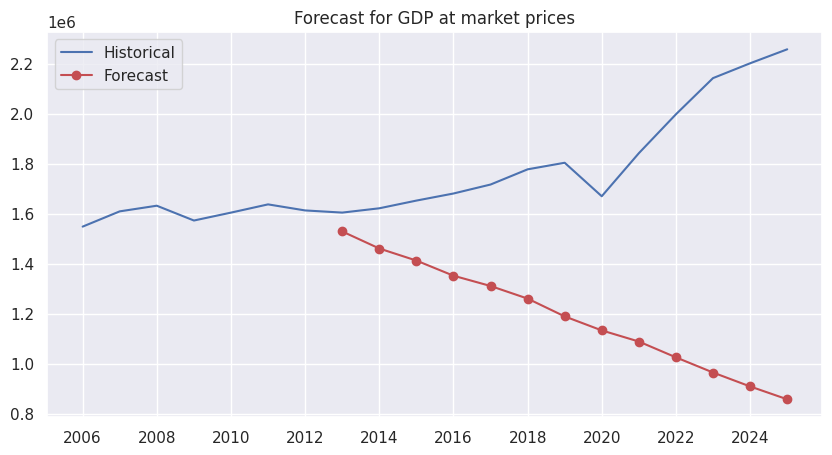

In [ ]:
var = 'GDP at market prices'
plt.figure(figsize=(10,5))
plt.plot(df[-20:].index, df[-20:][var], label='Historical')
plt.plot(forecast_df.index, forecast_df[var], 'ro-', label='Forecast')
plt.title(f'Forecast for {var}')
plt.legend()
plt.show()

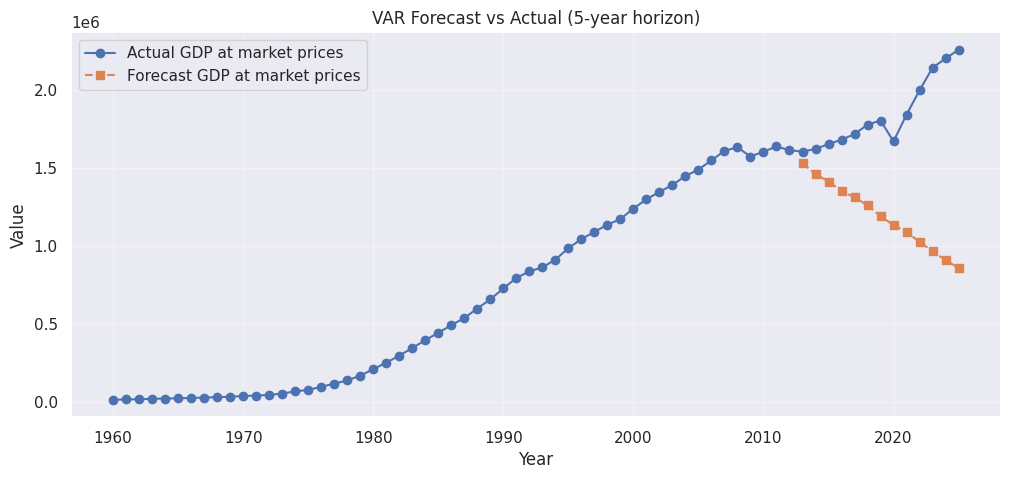

In [ ]:
plt.figure(figsize=(12, 5))
test = df[10:]
for var in df.columns[:1]:   # first three variables
    plt.plot(test.index, test[var], 'o-', label=f'Actual {var}')
    plt.plot(forecast_df.index, forecast_df[var], 's--', label=f'Forecast {var}')
plt.title('VAR Forecast vs Actual (5‑year horizon)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ARIMA

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

Manual differentiation + ARMA

In [ ]:
gdp = df['GDP at market prices'].astype(float)
gdp_bc_vals, lam_gdp = boxcox(gdp)
gdp_bc = pd.Series(gdp_bc_vals, index=gdp.index, name='GDP_bc')

print(f"Lambda Box–Cox для GDP: {lam_gdp:.4f}")

gdp_bc_diff = gdp_bc.diff().dropna()
# gdp_bc_diff = gdp_bc.dropna()
adf_test(gdp, 'GDP (уровень)')
adf_test(gdp_bc, 'GDP Box–Cox (уровень)')
adf_test(gdp_bc_diff, 'GDP Box–Cox (1-я разность)')

test_horizon = 10
train_diff = gdp_bc_diff.iloc[:-test_horizon]
test_diff = gdp_bc_diff.iloc[-test_horizon:]

Lambda Box–Cox для GDP: 0.2325
--- GDP (уровень) ---
ADF Statistic: 2.307499
p-value: 0.998960
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)

--- GDP Box–Cox (уровень) ---
ADF Statistic: -1.365491
p-value: 0.598704
Critical values: {'1%': np.float64(-3.526004646825607), '5%': np.float64(-2.9032002348069774), '10%': np.float64(-2.5889948363419957)}
=> Non-stationary (fail to reject H0)

--- GDP Box–Cox (1-я разность) ---
ADF Statistic: -2.161435
p-value: 0.220539
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

Топ-5 моделей по AIC:
        order        aic         bic
11  (2, 0, 3)  93.235711  108.456421
12  (3, 0, 0)  96.013903  106.885840
13  (3, 0, 1)  97.895716  110.942040
7   (1, 0, 3)  98.349401  111.395724
14  (3, 0, 2)  99.495789  114.716500

Топ-5 моделей по BIC:
        order         aic         bic
12  (3, 0, 0)   96.013903  106.885840
11  (2, 0, 3)   93.235711  108.456421
4   (1, 0, 0)  102.072816  108.595978
5   (1, 0, 1)  100.858371  109.555921
13  (3, 0, 1)   97.895716  110.942040

Выбранный порядок (по AIC): (2, 0, 3)
                               SARIMAX Results                                
Dep. Variable:                 GDP_bc   No. Observations:                   65
Model:                 ARIMA(2, 0, 3)   Log Likelihood                 -39.618
Date:                Mon, 29 Jun 2026   AIC                             93.236
Time:                        11:02:14   BIC                            108.456
Sample:                    01-01-1951   HQIC                           

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE (тест):  158,070.00
RMSE (тест): 40,660,350,304.80


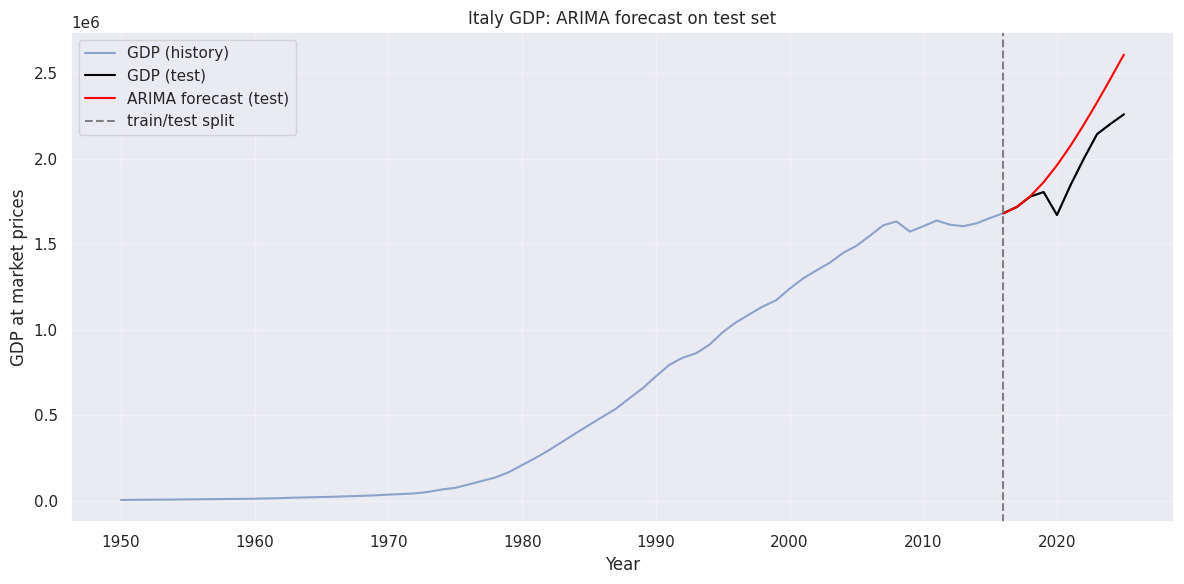

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

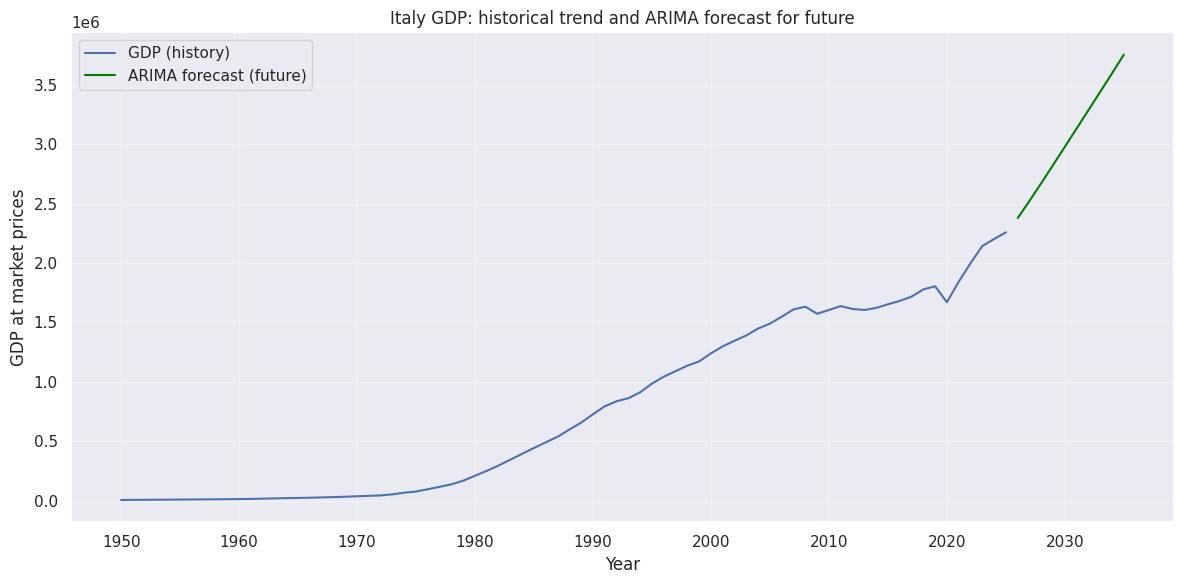

Forecast GDP for future:
2026-01-01    2.378037e+06
2027-01-01    2.522723e+06
2028-01-01    2.672679e+06
2029-01-01    2.825261e+06
2030-01-01    2.978921e+06
2031-01-01    3.132933e+06
2032-01-01    3.287153e+06
2033-01-01    3.441824e+06
2034-01-01    3.597418e+06
2035-01-01    3.754522e+06
Freq: YS-JAN, Name: GDP_forecast, dtype: float64


In [ ]:


p_range = range(0, 4)   # 0, 1, 2, 3
d_range = [0]
q_range = range(0, 4)   # 0, 1, 2, 3

results = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    order = (p, d, q)
    try:
        model = ARIMA(train_diff, order=order)
        res = model.fit()
        results.append({
            'order': order,
            'aic': res.aic,
            'bic': res.bic
        })
    except Exception:
        continue

results_df = pd.DataFrame(results)

print("Топ-5 моделей по AIC:")
print(results_df.nsmallest(5, 'aic'))

print("\nТоп-5 моделей по BIC:")
print(results_df.nsmallest(5, 'bic'))

best_order_aic = tuple(results_df.nsmallest(1, 'aic').iloc[0]['order'])
print("\nВыбранный порядок (по AIC):", best_order_aic)

best_model = ARIMA(train_diff, order=best_order_aic)
best_fit = best_model.fit()
print(best_fit.summary())

forecast_res = best_fit.get_forecast(steps=len(test_diff))
pred_diff = forecast_res.predicted_mean


first_test_idx = test_diff.index[0]

pos = gdp_bc.index.get_loc(first_test_idx)
last_level_bc = gdp_bc.iloc[pos - 1]

pred_level_bc = last_level_bc + pred_diff.cumsum()
pred_level_bc = pd.Series(pred_level_bc, index=test_diff.index, name='GDP_bc_pred')

pred_level = inv_boxcox(pred_level_bc, lam_gdp)
pred_level = pd.Series(pred_level, index=test_diff.index, name='GDP_pred')

real_test = gdp.loc[test_diff.index]

mae = mean_absolute_error(real_test, pred_level)
rmse = mean_squared_error(real_test, pred_level)
print(f"MAE (тест):  {mae:,.2f}")
print(f"RMSE (тест): {rmse:,.2f}")

plt.figure(figsize=(12, 6))
plt.plot(gdp.index, gdp, label='GDP (history)', alpha=0.6)
plt.plot(real_test.index, real_test, label='GDP (test)', color='black')
plt.plot(pred_level.index, pred_level, label='ARIMA forecast (test)', color='red')
plt.axvline(real_test.index[0], color='grey', linestyle='--', label='train/test split')
plt.title('Italy GDP: ARIMA forecast on test set')
plt.xlabel('Year')
plt.ylabel('GDP at market prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


steps_ahead = 10


full_fit = ARIMA(gdp_bc_diff, order=best_order_aic).fit()
future_diff = full_fit.get_forecast(steps=steps_ahead).predicted_mean

last_level_bc_full = gdp_bc.iloc[-1]
future_level_bc = last_level_bc_full + future_diff.cumsum()
future_level = inv_boxcox(future_level_bc, lam_gdp)


last_date = gdp.index[-1]
future_index = pd.date_range(start=last_date + pd.DateOffset(years=1),
                             periods=steps_ahead,
                             freq='YS')

future_series = pd.Series(future_level.values, index=future_index, name='GDP_forecast')


plt.figure(figsize=(12, 6))
plt.plot(gdp.index, gdp, label='GDP (history)')
plt.plot(future_series.index, future_series, label='ARIMA forecast (future)', color='green')
plt.title('Italy GDP: historical trend and ARIMA forecast for future')
plt.xlabel('Year')
plt.ylabel('GDP at market prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Forecast GDP for future:")
print(future_series)

ARIMA

In [ ]:
gdp = df['GDP at market prices'].astype(float)
gdp_bc_vals, lam_gdp = boxcox(gdp)
gdp_bc = pd.Series(gdp_bc_vals, index=gdp.index, name='GDP_bc')

print(f"Lambda Box–Cox для GDP: {lam_gdp:.4f}")

# ADF-тесты на уровнях (разности больше не нужны для сплита)
adf_test(gdp,     'GDP (уровень)')
adf_test(gdp_bc,  'GDP Box–Cox (уровень)')

# Сплит на train/test по УРОВНЯМ BoxCox (не по разностям)
test_horizon = 10
train_bc = gdp_bc.iloc[:-test_horizon]
test_bc  = gdp_bc.iloc[-test_horizon:]

Lambda Box–Cox для GDP: 0.2325
--- GDP (уровень) ---
ADF Statistic: 2.307499
p-value: 0.998960
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)

--- GDP Box–Cox (уровень) ---
ADF Statistic: -1.365491
p-value: 0.598704
Critical values: {'1%': np.float64(-3.526004646825607), '5%': np.float64(-2.9032002348069774), '10%': np.float64(-2.5889948363419957)}
=> Non-stationary (fail to reject H0)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

Top-5 models AIC:
         order        aic         bic
100  (6, 2, 2)  92.139818  111.569766
32   (2, 2, 6)  92.217355  111.647303
27   (2, 2, 1)  93.421583  102.057116
118  (7, 2, 2)  93.683481  115.272311
101  (6, 2, 3)  94.041913  115.630744

Top-5 models BIC:
        order        aic         bic
27  (2, 2, 1)  93.421583  102.057116
9   (1, 2, 1)  97.831006  104.307655
11  (1, 2, 3)  94.374888  105.169303
10  (1, 2, 2)  96.639612  105.275144
45  (3, 2, 1)  95.016404  105.810819
Best order (AIC): (6, 2, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                 GDP_bc   No. Observations:                   66
Model:                 ARIMA(6, 2, 2)   Log Likelihood                 -37.070
Date:                Wed, 01 Jul 2026   AIC                             92.140
Time:                        08:32:51   BIC                            111.570
Sample:                    01-01-1950   HQIC                            99.794
                         - 01-01-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1651      0.176      0.939      0.348      -0.179       0.510
ar.L2         -0.9997      0.178     -5.612      0.000      -1.349      -0.651
ar.L3         -0.0650      0.218     -0.298      0.7

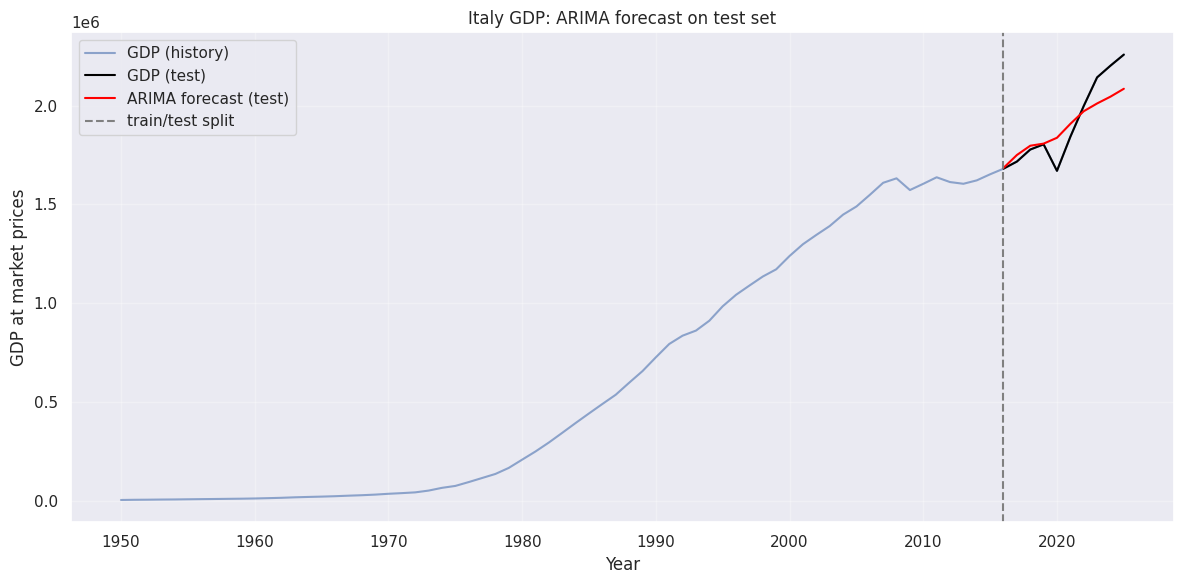

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


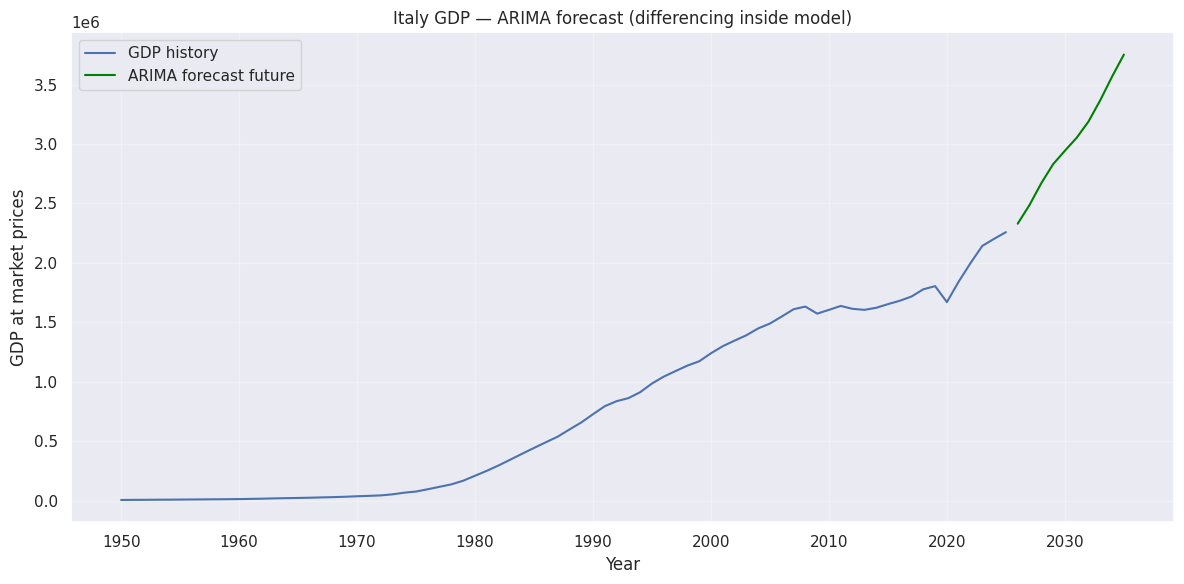

In [ ]:


p_range = range(1, 10)
d_range = [1,2]
q_range = range(1, 10)

results = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    order = (p, d, q)
    try:
        model = ARIMA(train_bc, order=order)
        res = model.fit()
        results.append({'order': order, 'aic': res.aic, 'bic': res.bic})
    except Exception:
        continue

results_df = pd.DataFrame(results)
print("Top-5 models AIC:")
print(results_df.nsmallest(5, 'aic'))

print("\nTop-5 models BIC:")
print(results_df.nsmallest(5, 'bic'))
bestorder_aic = tuple(results_df.nsmallest(1, 'aic').iloc[0]['order'])
print("Best order (AIC):", bestorder_aic)

bestmodel = ARIMA(train_bc, order=bestorder_aic)
bestfit = bestmodel.fit()
print(bestfit.summary())

forecast_res = bestfit.get_forecast(steps=len(test_bc))
pred_bc = forecast_res.predicted_mean

pred_level = inv_boxcox(pred_bc.values, lam_gdp)
pred_level = pd.Series(pred_level, index=test_bc.index, name='GDP_pred')

real_test = gdp.loc[test_bc.index]
mae  = mean_absolute_error(real_test, pred_level)
rmse = mean_squared_error(real_test, pred_level) ** 0.5
mape = mean_absolute_percentage_error(real_test, pred_level) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(gdp.index, gdp, label='GDP (history)', alpha=0.6)
plt.plot(real_test.index, real_test, label='GDP (test)', color='black')
plt.plot(pred_level.index, pred_level, label='ARIMA forecast (test)', color='red')
plt.axvline(real_test.index[0], color='grey', linestyle='--', label='train/test split')
plt.title('Italy GDP: ARIMA forecast on test set')
plt.xlabel('Year')
plt.ylabel('GDP at market prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


steps_ahead = 10

full_fit = ARIMA(gdp_bc, order=bestorder_aic).fit()

future_bc = full_fit.get_forecast(steps=steps_ahead).predicted_mean
futurelevel = inv_boxcox(future_bc.values, lam_gdp)

lastdate = gdp.index[-1]
futureindex = pd.date_range(
    start=lastdate + pd.DateOffset(years=1),
    periods=steps_ahead, freq='YS'
)

futureseries = pd.Series(futurelevel, index=futureindex, name='GDP_forecast')

plt.figure(figsize=(12, 6))
plt.plot(gdp.index, gdp, label='GDP history')
plt.plot(futureseries.index, futureseries, label='ARIMA forecast future', color='green')
plt.title('Italy GDP — ARIMA forecast (differencing inside model)')
plt.xlabel('Year')
plt.ylabel('GDP at market prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()